# M15 — Notebook de Baseline e Avaliação Inicial
**LGN 2026.3 — Aula 5**

Objetivo: construir e interpretar uma primeira referência de desempenho, comparando uma referência majoritária simples com um classificador supervisionado. O conjunto de teste permanecerá preservado e **não será transformado, previsto, avaliado nem usado para orientar decisões nesta aula**.


## 1. Carregar o corpus vigente
Escolha o arquivo do seu grupo. Os três corpora fornecidos já contêm `particao_recomendada`.


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

ARQUIVO = "P03_solicitacoes_atendimento.csv"  # troque por P02 ou P03, se necessário
MAPA_ALVO = {
    "P01_reclamacoes_assunto.csv": "categoria_assunto",
    "P02_sentimento_avaliacoes.csv": "sentimento",
    "P03_solicitacoes_atendimento.csv": "setor_destino",
}
COL_TEXTO = "texto"
COL_ALVO = MAPA_ALVO[ARQUIVO]

df = pd.read_csv(ARQUIVO, sep=";", encoding="utf-8-sig")
print("Corpus:", ARQUIVO)
print("Dimensões originais:", df.shape)


Corpus: P03_solicitacoes_atendimento.csv
Dimensões originais: (240, 6)


## 2. Identificar texto e registros vazios
Registros sem texto não podem alimentar o vetorizador. Remova-os e registre quantos foram excluídos.

Nesta etapa, não inspecione nem use o conteúdo do alvo do conjunto de teste. A verificação de alvo vazio será feita somente em treino e validação, depois da separação pelas partições fornecidas.


In [41]:
print("Texto:", COL_TEXTO)
print("Alvo:", COL_ALVO)

n_vazios_texto = df[COL_TEXTO].isna().sum()
print("Textos vazios:", n_vazios_texto)

df_modelo = df.dropna(subset=[COL_TEXTO]).copy()
print("Registros após remover textos vazios:", len(df_modelo))


Texto: texto
Alvo: setor_destino
Textos vazios: 3
Registros após remover textos vazios: 237


## 3. Confirmar a estrutura necessária
Antes de olhar resultados, confirme se o arquivo contém as colunas necessárias e as partições fornecidas.

A presença da coluna de alvo é verificada estruturalmente, mas o conteúdo dos rótulos do teste não será inspecionado nesta aula.


In [42]:
colunas_necessarias = {COL_TEXTO, COL_ALVO, "particao_recomendada"}
faltantes = colunas_necessarias - set(df_modelo.columns)
assert not faltantes, f"Colunas ausentes: {faltantes}"

particoes_encontradas = sorted(df_modelo["particao_recomendada"].dropna().unique())
print("Partições encontradas:", particoes_encontradas)
assert {"treino", "validacao", "teste"}.issubset(set(particoes_encontradas))
print("Estrutura básica conferida.")


Partições encontradas: ['teste', 'treino', 'validacao']
Estrutura básica conferida.


## 4. Conferir treino, validação e teste
O corpus já traz `particao_recomendada`. Não refaça a divisão.

Nesta aula:
- inspecione a distribuição das respostas em **treino** e **validação**;
- verifique alvo vazio somente em **treino** e **validação**;
- confirme apenas a **contagem** do teste;
- confira as contagens esperadas do pacote didático;
- não use os rótulos do teste para orientar decisões.


In [43]:
treino = df_modelo[df_modelo["particao_recomendada"] == "treino"].copy()
validacao = df_modelo[df_modelo["particao_recomendada"] == "validacao"].copy()
teste = df_modelo[df_modelo["particao_recomendada"] == "teste"].copy()

# Conferência do alvo apenas onde ele será usado nesta aula.
n_alvo_vazio_treino = treino[COL_ALVO].isna().sum()
n_alvo_vazio_validacao = validacao[COL_ALVO].isna().sum()

print("Alvos vazios no treino:", n_alvo_vazio_treino)
print("Alvos vazios na validação:", n_alvo_vazio_validacao)

assert n_alvo_vazio_treino == 0, "Há alvo vazio no treino; interrompa e revise os dados."
assert n_alvo_vazio_validacao == 0, "Há alvo vazio na validação; interrompa e revise os dados."

print("\nTreino — dados usados para aprender:", len(treino))
display(treino[COL_ALVO].value_counts().to_frame("quantidade"))

print("\nValidação — dados usados para comparar:", len(validacao))
display(validacao[COL_ALVO].value_counts().to_frame("quantidade"))

print("\nTeste preservado — apenas contagem:", len(teste))

CONTAGENS_ESPERADAS = {
    "P01_reclamacoes_assunto.csv": {"treino": 138, "validacao": 49, "teste": 50},
    "P02_sentimento_avaliacoes.csv": {"treino": 139, "validacao": 49, "teste": 49},
    "P03_solicitacoes_atendimento.csv": {"treino": 139, "validacao": 49, "teste": 49},
}

esperado = CONTAGENS_ESPERADAS[ARQUIVO]
observado = {
    "treino": len(treino),
    "validacao": len(validacao),
    "teste": len(teste),
}

print("\nContagens observadas:", observado)
print("Contagens esperadas:", esperado)

assert observado == esperado, (
    "As contagens divergem do pacote didático. "
    "Verifique arquivo, leitura e remoção de textos vazios antes de continuar."
)

assert len(treino) > 0 and len(validacao) > 0 and len(teste) > 0
assert set(validacao[COL_ALVO]).issubset(set(treino[COL_ALVO]))
assert set(treino.index).isdisjoint(set(validacao.index))
assert set(treino.index).isdisjoint(set(teste.index))
assert set(validacao.index).isdisjoint(set(teste.index))

display(treino.head())

print("\nPartições conferidas: treino e validação são viáveis para a comparação.")
print("O teste permanece preservado e não será transformado, previsto, avaliado ou usado para decidir nesta aula.")


Alvos vazios no treino: 0
Alvos vazios na validação: 0

Treino — dados usados para aprender: 139


,quantidade
setor_destino,
financeiro,34
secretaria_academica,31
suporte_tecnico,29
biblioteca,24
coordenacao,21



Validação — dados usados para comparar: 49


,quantidade
setor_destino,
financeiro,12
secretaria_academica,11
suporte_tecnico,10
biblioteca,9
coordenacao,7



Teste preservado — apenas contagem: 49

Contagens observadas: {'treino': 139, 'validacao': 49, 'teste': 49}
Contagens esperadas: {'treino': 139, 'validacao': 49, 'teste': 49}


,id,texto,setor_destino,canal,urgencia_referencia,particao_recomendada
4,ATE-0081,Preciso de ajuda: a matrícula em uma disciplin...,secretaria_academica,aplicativo,normal,treino
5,ATE-0010,"Olá, quero informações sobre bolsa e desconto ...",financeiro,aplicativo,normal,treino
6,ATE-0197,"Gente, quero saber como reservar um livro ...",biblioteca,aplicativo,normal,treino
7,ATE-0028,"Olá, quero informações sobre bolsa e desconto ...",financeiro,aplicativo,normal,treino
11,ATE-0137,"Gente, preciso enviar um documento à secretari...",suporte_tecnico,email,normal,treino



Partições conferidas: treino e validação são viáveis para a comparação.
O teste permanece preservado e não será transformado, previsto, avaliado ou usado para decidir nesta aula.


## 5. Calcular a referência majoritária
Esta referência simples repete sempre a resposta mais frequente do **treino** e não usa o conteúdo textual.

**Baseline** é a referência simples; os valores calculados na validação são os resultados produzidos por ela. Isso não a torna um modelo recomendado nem um valor que obrigatoriamente precise ser superado.


In [44]:
resposta_mais_frequente = treino[COL_ALVO].mode().iloc[0]
pred_majoritaria = [resposta_mais_frequente] * len(validacao)

acc_majoritaria = accuracy_score(validacao[COL_ALVO], pred_majoritaria)
f1_majoritaria = f1_score(
    validacao[COL_ALVO],
    pred_majoritaria,
    average="macro",
    zero_division=0,
)

print("Resposta mais frequente do treino:", resposta_mais_frequente)
print(f"Acurácia — referência majoritária: {acc_majoritaria:.3f}")
print(f"F1-macro — referência majoritária: {f1_majoritaria:.3f}")


Resposta mais frequente do treino: financeiro
Acurácia — referência majoritária: 0.245
F1-macro — referência majoritária: 0.079


## 6. Construir a representação TF-IDF
Use a configuração TF-IDF definida para esta comparação. O vocabulário e o IDF deverão ser aprendidos somente com os textos de treino.


In [45]:
vetorizador = TfidfVectorizer(ngram_range=(1, 1))
print("Representação:", "TF-IDF com unigramas")


Representação: TF-IDF com unigramas


## 7. Ajustar no treino e transformar a validação
`fit_transform` aprende e aplica a representação no treino. A validação recebe apenas `transform`.

O teste permanece guardado, sem transformação, previsão, métrica ou participação em qualquer decisão nesta aula.


In [46]:
X_treino = vetorizador.fit_transform(treino[COL_TEXTO])
X_validacao = vetorizador.transform(validacao[COL_TEXTO])

y_treino = treino[COL_ALVO]
y_validacao = validacao[COL_ALVO]

print("Matriz de treino:", X_treino.shape)
print("Matriz de validação:", X_validacao.shape)
assert X_treino.shape[1] == X_validacao.shape[1]
print("Teste preservado: nenhuma matriz de teste foi criada.")


Matriz de treino: (139, 164)
Matriz de validação: (49, 164)
Teste preservado: nenhuma matriz de teste foi criada.


## 8. Treinar o classificador supervisionado
A Regressão Logística será usada como ferramenta de classificação com configuração fixa, sem tuning. O ajuste usa apenas os números e os rótulos do treino; as previsões são produzidas somente para a validação.


In [47]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_treino, y_treino)

pred_validacao = modelo.predict(X_validacao)
print("Previsões de validação geradas:", len(pred_validacao))


Previsões de validação geradas: 49


## 9. Calcular acurácia e F1-macro
A acurácia responde quantas previsões ficaram corretas no total.

Nesta aula, trate o F1 como um indicador do desempenho de uma classe. O F1-macro calcula a média dos valores de F1 das classes, dando o mesmo peso a cada uma. As duas evidências devem ser lidas em conjunto.


In [48]:
acc_modelo = accuracy_score(y_validacao, pred_validacao)
f1_modelo = f1_score(
    y_validacao,
    pred_validacao,
    average="macro",
    zero_division=0,
)

print("Referência majoritária")
print(f"Acurácia — referência majoritária: {acc_majoritaria:.3f}")
print(f"F1-macro — referência majoritária: {f1_majoritaria:.3f}")

print("\nClassificador supervisionado")
print(f"Acurácia — supervisionado: {acc_modelo:.3f}")
print(f"F1-macro — supervisionado: {f1_modelo:.3f}")


Referência majoritária
Acurácia — referência majoritária: 0.245
F1-macro — referência majoritária: 0.079

Classificador supervisionado
Acurácia — supervisionado: 1.000
F1-macro — supervisionado: 1.000


## 10. Localizar acertos e erros
Antes de interpretar a tabela, observe:

- onde estão os acertos?
- onde estão os erros?
- alguma classe parece ser ignorada ou confundida com outra?

A tabela gerada a seguir é a **matriz de confusão**. As linhas representam as respostas conhecidas e as colunas, as respostas previstas. Ela é uma evidência de avaliação, não uma terceira métrica escalar.


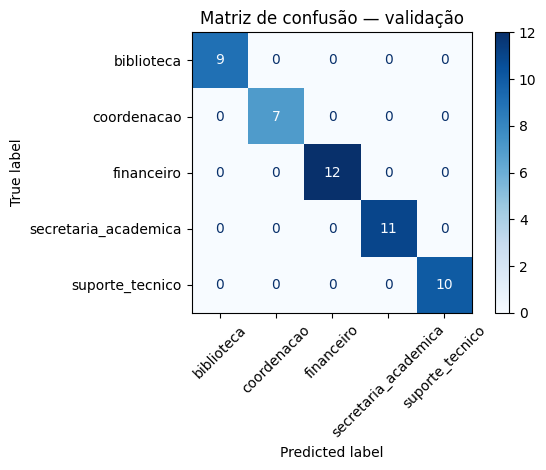

Linhas = resposta conhecida | Colunas = resposta prevista


In [49]:
classes = sorted(y_treino.unique())
cm = confusion_matrix(y_validacao, pred_validacao, labels=classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes,
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusão — validação")
plt.tight_layout()
plt.show()

print("Linhas = resposta conhecida | Colunas = resposta prevista")


## Microexperimento de vazamento — TEMPORÁRIO / INCORRETO
Este experimento serve somente para rastrear a origem da informação. Ele não busca aumentar métricas e não produz uma decisão sobre o classificador.

Mantenha `EXECUTAR_TEMPORARIO = False` na execução normal.

Se for ativado para demonstração, o código ajustará indevidamente **outro vetorizador em treino + validação**. O teste continuará completamente fora do experimento. Em seguida, o objeto temporário será descartado e o fluxo correto permanecerá inalterado.


In [50]:
EXECUTAR_TEMPORARIO = False

if EXECUTAR_TEMPORARIO:
    tfidf_incorreto = TfidfVectorizer()

    textos_treino_validacao = pd.concat(
        [treino[COL_TEXTO], validacao[COL_TEXTO]],
        ignore_index=True,
    )

    X_treino_validacao_incorreto = tfidf_incorreto.fit_transform(
        textos_treino_validacao
    )

    print("TEMPORÁRIO / INCORRETO")
    print(
        "Origem indevida: treino + validação participaram do fit:",
        X_treino_validacao_incorreto.shape,
    )
    print("O teste permaneceu fora do experimento.")
    print("O objetivo é rastrear a origem da informação, não comparar métricas.")

    del tfidf_incorreto, X_treino_validacao_incorreto, textos_treino_validacao
    EXECUTAR_TEMPORARIO = False
else:
    print("Experimento não executado: nenhum fit adicional foi realizado.")

assert EXECUTAR_TEMPORARIO is False
print(
    "Fluxo correto preservado: TF-IDF ajustado no treino; "
    "validação apenas transformada; teste intocado."
)


Experimento não executado: nenhum fit adicional foi realizado.
Fluxo correto preservado: TF-IDF ajustado no treino; validação apenas transformada; teste intocado.


## 11. Interpretar e registrar o resultado observado
Preencha após executar as células anteriores. Não há regra automática de “superou”, “aprovado” ou “bom”.

Interprete acurácia, F1-macro e matriz de confusão no contexto **desta validação**.

Use formulações como:
- **“Nesta validação, observamos que...”**
- **“Esse resultado ainda não permite concluir que...”**

O teste continua preservado.


In [51]:
registro_final = {
    "corpus": ARQUIVO,
    "referencia_majoritaria": {
        "acuracia": round(acc_majoritaria, 3),
        "f1_macro": round(f1_majoritaria, 3),
    },
    "classificador_supervisionado": {
        "acuracia": round(acc_modelo, 3),
        "f1_macro": round(f1_modelo, 3),
    },
    "matriz_de_confusao_principal_padrao": "Sem confusão entre setores na validação: todas as 49 mensagens foram atribuídas ao setor correto pelo classificador.",
    "interpretacao": "Nesta validação, O classificador foi muito melhor que o chute simples: acurácia 1,000 contra 0,245, e F1-macro 1,000 contra 0,079. O chute simples erra porque sempre responde `financeiro`. O classificador aprendeu a diferenciar os setores pelas palavras de cada mensagem.",
    "limitacao": "O resultado de 100% deve ser visto com cautela, pois o corpus é sintético e pequeno. Isso não garante o mesmo desempenho com mensagens reais, mais confusas. O teste ainda não foi usado e precisa ser conferido depois.",
    "referencia_para_aula_6": "O classificador com TF-IDF (acurácia 1,000, F1 1,000) é a referência de comparação, contra o chute simples (0,245 e 0,079). Próximo passo: testar outras representações e casos mais difíceis antes de usar o teste.",
}
display(registro_final)

print("Responda sem aplicar uma regra automática:")
print("1. Qual foi o resultado da referência majoritária?")
print("2. Qual foi o resultado do classificador supervisionado?")
print("3. O que a acurácia mostra?")
print("4. O que o F1-macro acrescenta à leitura?")
print("5. O que a matriz de confusão mostra sobre os acertos e erros?")
print("6. Nesta validação, o que podemos afirmar?")
print("7. Qual limitação precisa ser registrada?")
print("8. Qual resultado servirá de referência de comparação na Aula 6?")

print("\nREGISTRO DO M15")
print("Corpus:", ARQUIVO)
print(
    f"\nReferência majoritária:"
    f"\nAcurácia = {acc_majoritaria:.3f}"
    f"\nF1-macro = {f1_majoritaria:.3f}"
)
print(
    f"\nClassificador supervisionado:"
    f"\nAcurácia = {acc_modelo:.3f}"
    f"\nF1-macro = {f1_modelo:.3f}"
)
print("\nMatriz de confusão:\nprincipal padrão observado = ______________________")
print("\nInterpretação:\nNesta validação, __________________________________")
print("\nLimitação:\n__________________________________")
print("\nReferência para a Aula 6:\n__________________________________")


{'corpus': 'P03_solicitacoes_atendimento.csv',
 'referencia_majoritaria': {'acuracia': 0.245, 'f1_macro': 0.079},
 'classificador_supervisionado': {'acuracia': 1.0, 'f1_macro': 1.0},
 'matriz_de_confusao_principal_padrao': 'Sem confusão entre setores na validação: todas as 49 mensagens foram atribuídas ao setor correto pelo classificador.',
 'interpretacao': 'Nesta validação, O classificador foi muito melhor que o chute simples: acurácia 1,000 contra 0,245, e F1-macro 1,000 contra 0,079. O chute simples erra porque sempre responde `financeiro`. O classificador aprendeu a diferenciar os setores pelas palavras de cada mensagem.',
 'limitacao': 'O resultado de 100% deve ser visto com cautela, pois o corpus é sintético e pequeno. Isso não garante o mesmo desempenho com mensagens reais, mais confusas. O teste ainda não foi usado e precisa ser conferido depois.',
 'referencia_para_aula_6': 'O classificador com TF-IDF (acurácia 1,000, F1 1,000) é a referência de comparação, contra o chute sim

Responda sem aplicar uma regra automática:
1. Qual foi o resultado da referência majoritária?
2. Qual foi o resultado do classificador supervisionado?
3. O que a acurácia mostra?
4. O que o F1-macro acrescenta à leitura?
5. O que a matriz de confusão mostra sobre os acertos e erros?
6. Nesta validação, o que podemos afirmar?
7. Qual limitação precisa ser registrada?
8. Qual resultado servirá de referência de comparação na Aula 6?

REGISTRO DO M15
Corpus: P03_solicitacoes_atendimento.csv

Referência majoritária:
Acurácia = 0.245
F1-macro = 0.079

Classificador supervisionado:
Acurácia = 1.000
F1-macro = 1.000

Matriz de confusão:
principal padrão observado = ______________________

Interpretação:
Nesta validação, __________________________________

Limitação:
__________________________________

Referência para a Aula 6:
__________________________________
